# Checkpoint 4 — Questão 2
## Gestão inteligente do consumo de energia

**Turma W — Algoritmos e Estruturas de Dados — FIAP**

**Grupo Resiliência** · Identificador `ESPW-RESILIENCIA` · Semente `SEED = 1128587`

| Integrante | RM |
|---|---|
| Kauã Gabriel Moreira E Silva | RM566043 |
| Mariana Silva do Egito Moreira | RM562544 |

A seed é a soma dos RMs dos integrantes (566043 + 562544).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))
from IPython.display import Image, display

from src import config
from src.gerar_dados import gerar_serie, salvar_serie
from src.estruturas import IndiceConsumo
import pandas as pd

serie = gerar_serie(config.N_OBSERVACOES, config.SEED)
salvar_serie(serie)
idx = IndiceConsumo(serie)

print(f"observacoes : {len(serie)} (minimo exigido: 1000)")
print(f"periodo     : {serie[0].timestamp} -> {serie[-1].timestamp}")
print(f"regioes     : {sorted(idx.regioes)}")
pd.DataFrame([vars(r) for r in serie[:5]])

observacoes : 1200 (minimo exigido: 1000)
periodo     : 2026-01-01 00:00:00 -> 2026-02-19 23:00:00
regioes     : ['Centro-Oeste', 'Nordeste', 'Norte', 'Sudeste', 'Sul']


,indice,timestamp,regiao,consumo,capacidade,prioridade,custo
0,0,2026-01-01 00:00:00,Sudeste,716.58,1450.0,5,300.96
1,1,2026-01-01 01:00:00,Sul,443.03,1050.0,1,186.07
2,2,2026-01-01 02:00:00,Nordeste,522.98,1200.0,1,219.65
3,3,2026-01-01 03:00:00,Norte,292.48,800.0,3,122.84
4,4,2026-01-01 04:00:00,Centro-Oeste,341.25,950.0,2,143.33


### Processo de geração (documentado e reprodutível)

```
consumo = base_regiao × sazonalidade_diaria(hora) × tendencia(t) × (1 + ruído)
          + evento_de_pico
```

* `sazonalidade_diaria` reproduz o perfil brasileiro: vale entre 3h e 5h, ponta
  entre 18h e 21h (dois termos gaussianos + uma senoide).
* `tendencia` cresce 0,008% por hora, o crescimento lento da demanda.
* `ruído ~ U(-8%, +8%)`.
* Eventos de pico (1 a cada 250 horas) multiplicam o consumo por 1,25 a 1,55
  durante 8 a 30 horas contíguas, são as janelas que o algoritmo precisa achar.
* Custo marginal sobe quando a utilização passa de 100% (acionamento de térmica
  de ponta).

Tudo depende só de `SEED`; rodar de novo reproduz exatamente a mesma série.

## Parte A — Estruturação dos dados

Cinco estruturas, cada uma com a operação que a justifica:

| Estrutura | Uso | Vantagem concreta |
|---|---|---|
| `list` | `idx.serie` e o vetor de criticidades | preserva **ordem temporal** e dá acesso `O(1)` por índice — o problema inteiro depende de contiguidade, coisa que `dict` e `set` não representam |
| `dict` | índices invertidos `região → posições` e `hora → posições` | consulta por região/horário em `O(1)` + leitura só dos elementos relevantes, contra `O(n)` de varredura |
| `tuple` (`dataclass frozen`) | cada `Registro`; resultado `(i, j, valor)` | imutável e hashável: os dois algoritmos veem exatamente a mesma série, o que torna a comparação legítima |
| `set` | `idx.regioes`, `idx.horas_criticas()` | pertinência em `O(1)` médio e deduplicação sem ordenar |
| `heap` | `idx.top_k_picos(k)` | top-k em `O(n log k)` com heap de tamanho fixo, em vez de `O(n log n)` ordenando tudo |

Além delas, uma **lista de somas de prefixo** responde "consumo acumulado em
[i, j]" em `O(1)` após um pré-processamento `O(n)`.

In [2]:
print("consumo por regiao (dict -> indice invertido):")
for r in sorted(idx.regioes):
    print(f"  {r:<14} total={idx.consumo_regiao(r):12,.0f} MWh  registros={len(idx.por_regiao[r])}")

print("\ntop-5 picos (heap de tamanho 5):")
for consumo, pos in idx.top_k_picos(5):
    print(f"  {serie[pos].timestamp}  {serie[pos].regiao:<14} {consumo:8.1f} MWh")

print("\nhoras criticas (set, consumo > 90% da capacidade):", sorted(idx.horas_criticas()))
print("soma de consumo em [100, 200] via prefixos:", f"{idx.soma_intervalo(100, 200):,.1f}")

consumo por regiao (dict -> indice invertido):
  Centro-Oeste   total=     152,168 MWh  registros=240
  Nordeste       total=     198,696 MWh  registros=240
  Norte          total=     128,292 MWh  registros=240
  Sudeste        total=     233,786 MWh  registros=240
  Sul            total=     168,524 MWh  registros=240

top-5 picos (heap de tamanho 5):
  2026-02-14 19:00:00  Sudeste          1671.6 MWh
  2026-01-28 17:00:00  Sudeste          1610.3 MWh
  2026-01-04 13:00:00  Sudeste          1557.7 MWh
  2026-01-29 13:00:00  Sudeste          1495.3 MWh
  2026-02-09 19:00:00  Sudeste          1395.5 MWh

horas criticas (set, consumo > 90% da capacidade): [9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21]
soma de consumo em [100, 200] via prefixos: 70,379.4


### Função de criticidade

$$ c_i = 100\,(u_i - \theta) \;+\; 100\gamma \max(0,\, u_i - 1) \;+\; w_p (p_i - \bar{p}) \;+\; w_c\left(\frac{\$_i}{\$_{med}} - 1\right)\cdot 10 $$

com $u_i = $ consumo/capacidade, $\theta = 0{,}85$, $\gamma = 1{,}5$,
$w_p = 6$, $\bar p = 3$, $w_c = 4$.

O ponto central é a **centragem em $\theta$**: abaixo de 85% de utilização a
parcela é *negativa*. Se todos os $c_i$ fossem positivos, o intervalo de maior
soma seria trivialmente a série inteira. Com sinais mistos, o problema vira
genuinamente "subsequência contígua de soma máxima". Como $c_i$ depende só da
medição $i$, a criticidade de um intervalo é **aditiva**, e é essa aditividade
que permite tanto as somas de prefixo quanto a fase COMBINE do divide and
conquer.

In [3]:
from src.criticidade import calcular_criticidade, descrever

valores = calcular_criticidade(serie)
print(descrever(valores))

exemplos = pd.DataFrame([{
    "timestamp": serie[i].timestamp, "regiao": serie[i].regiao,
    "consumo": serie[i].consumo, "capacidade": serie[i].capacidade,
    "utilizacao": round(serie[i].consumo/serie[i].capacidade, 3),
    "prioridade": serie[i].prioridade, "criticidade": valores[i],
} for i in [0, 1, 2, valores.index(max(valores)), valores.index(min(valores))]])
exemplos

n=1200 | positivos=370 (30.8%) | min=-83.80 | max=139.12 | soma=-19056.07


,timestamp,regiao,consumo,capacidade,utilizacao,prioridade,criticidade
0,2026-01-01 00:00:00,Sudeste,716.58,1450.0,0.494,5,-22.8905
1,2026-01-01 01:00:00,Sul,443.03,1050.0,0.422,1,-69.6497
2,2026-01-01 02:00:00,Nordeste,522.98,1200.0,0.436,1,-63.7214
3,2026-02-14 19:00:00,Sudeste,1671.58,1450.0,1.153,5,139.1187
4,2026-01-11 03:00:00,Norte,292.66,800.0,0.366,1,-83.7985


## Parte B — Força bruta

Duas versões explícitas, nenhuma com função pronta:

* `forca_bruta_cubica` — enumera todos os pares `(i, j)` e **recalcula** a soma:
  `Θ(n³)`. É a tradução literal do enunciado, usada como referência de correção.
* `forca_bruta` — enumera os mesmos `n(n+1)/2` intervalos, mas estende a soma em
  `O(1)` ao avançar `j`: `Θ(n²)`. É a versão levada ao experimento.

In [4]:
from src.brute_force import forca_bruta, forca_bruta_cubica

bf = forca_bruta(valores)
print(bf)
print(f"intervalo [{bf.inicio}, {bf.fim}] = {bf.tamanho} horas")
print(f"de {serie[bf.inicio].timestamp} ate {serie[bf.fim].timestamp}")
print(f"criticidade acumulada: {bf.valor:.2f}")
print(f"intervalos avaliados : {bf.operacoes:,} = n(n+1)/2 = {len(valores)*(len(valores)+1)//2:,}")

pequeno = valores[:120]
print("\nn=120: cubica e quadratica concordam?",
      forca_bruta_cubica(pequeno).valor == forca_bruta(pequeno).valor,
      f"| operacoes: {forca_bruta_cubica(pequeno).operacoes:,} vs {forca_bruta(pequeno).operacoes:,}")

ResultadoIntervalo(inicio=1070, fim=1077, valor=490.4163, operacoes=720600, algoritmo='forca_bruta')
intervalo [1070, 1077] = 8 horas
de 2026-02-14 14:00:00 ate 2026-02-14 21:00:00
criticidade acumulada: 490.42
intervalos avaliados : 720,600 = n(n+1)/2 = 720,600

n=120: cubica e quadratica concordam? True | operacoes: 295,240 vs 7,260


## Parte C — Dividir e conquistar

```
              DIVIDE  (m = (lo + hi) // 2)
                 |
        +--------+--------+
    SOLVE LEFT        SOLVE RIGHT
        +--------+--------+
                 |
          SOLVE CROSSING CASE
                 |
              COMBINE
```

* **Caso-base:** `lo == hi` → resposta é `c[lo]` (intervalo vazio não é
  permitido; por isso numa série toda negativa a resposta é o maior elemento).
* **Divisão:** por posição, no meio. Metades sempre balanceadas → profundidade
  `⌈log₂ n⌉`.
* **Subproblemas:** melhor intervalo contido só na esquerda e só na direita.
* **Caso que atravessa:** um intervalo ótimo pode começar antes de `m` e
  terminar depois, nenhuma das recursões o vê. Todo intervalo cruzado se
  escreve como `[i, m] ∪ [m+1, j]`; como as duas partes são independentes,
  maximiza-se cada uma separadamente: varre-se de `m` para a esquerda guardando
  o melhor sufixo e de `m+1` para a direita guardando o melhor prefixo. Custo
  linear no bloco.
* **Combinação:** `max` dos três candidatos; empate resolve pelo mais à
  esquerda, deixando a saída determinística.

Recorrência: `T(n) = 2T(n/2) + Θ(n)` → pelo Teorema Mestre (caso 2),
`T(n) = Θ(n log n)`.

In [5]:
from src.divide_conquer import intervalo_critico_dc, estatisticas_recursao

dc, raiz = intervalo_critico_dc(valores, construir_arvore=True, max_nivel_arvore=3)
print(dc)
print("mesma resposta da forca bruta?", (bf.inicio, bf.fim) == (dc.inicio, dc.fim),
      f"| valores: {bf.valor:.2f} vs {dc.valor:.2f}")
print(f"operacoes: forca bruta {bf.operacoes:,} | divide and conquer {dc.operacoes:,} "
      f"({bf.operacoes/dc.operacoes:.0f}x menos)")

est = estatisticas_recursao(valores)
for k, v in est.items():
    print(f"  {k:>28}: {v:,}")

ResultadoIntervalo(inicio=1070, fim=1077, valor=490.4163, operacoes=15950, algoritmo='divide_conquer')
mesma resposta da forca bruta? True | valores: 490.42 vs 490.42
operacoes: forca bruta 720,600 | divide and conquer 15,950 (45x menos)
                             n: 1,200
                      chamadas: 2,399
        chamadas_teoricas_2n_1: 2,399
                  profundidade: 11
    profundidade_teorica_log2n: 11
                     operacoes: 15,950


In [6]:
# Caminho da resposta pela arvore: de qual chamada ela veio?
no = raiz
while no.filhos:
    print(f"nivel {no.nivel}: [{no.lo}, {no.hi}] -> melhor {no.melhor[2]:.1f} (origem: {no.origem})")
    if no.origem == "cruzado":
        print("   ^ a resposta atravessa o meio: nenhuma das duas metades a continha inteira")
        break
    no = no.filhos[0] if no.origem == "esquerda" else no.filhos[1]

nivel 0: [0, 1199] -> melhor 490.4 (origem: direita)
nivel 1: [600, 1199] -> melhor 490.4 (origem: direita)
nivel 2: [900, 1199] -> melhor 490.4 (origem: direita)


## Parte D — Experimento de escalabilidade

In [7]:
from src.escalabilidade import experimento, salvar, razoes_empiricas

linhas = experimento()
salvar(linhas)

tab = pd.DataFrame(linhas)[["n", "algoritmo", "tempo_medio_s", "operacoes", "memoria_pico_kb"]]
tab.pivot(index="n", columns="algoritmo", values="tempo_medio_s")

n=  100 forca_bruta     t=0.00019s ops=      5050 mem=0.4KB
n=  100 divide_conquer  t=0.00014s ops=       970 mem=0.4KB
n=  250 forca_bruta     t=0.00110s ops=     31375 mem=0.4KB
n=  250 divide_conquer  t=0.00036s ops=      2742 mem=0.4KB


n=  500 forca_bruta     t=0.00543s ops=    125250 mem=0.8KB
n=  500 divide_conquer  t=0.00081s ops=      5986 mem=1.3KB


n= 1000 forca_bruta     t=0.02176s ops=    500500 mem=3.2KB
n= 1000 divide_conquer  t=0.00158s ops=     12974 mem=1.4KB


n= 2000 forca_bruta     t=0.08751s ops=   2001000 mem=0.4KB
n= 2000 divide_conquer  t=0.00333s ops=     27950 mem=1.6KB


n= 5000 forca_bruta     t=0.51956s ops=  12502500 mem=1.2KB
n= 5000 divide_conquer  t=0.00859s ops=     76806 mem=1.7KB


algoritmo,divide_conquer,forca_bruta
n,,
100,0.000140,0.000190
250,0.000362,0.001097
500,0.000808,0.005434
1000,0.001580,0.021759
2000,0.003325,0.087507
5000,0.008589,0.519564


In [8]:
razoes = razoes_empiricas(linhas)
for alg, lista in razoes.items():
    print(alg)
    for r in lista:
        print(f"   {r['de']:>5} -> {r['para']:>5}:  observado {r['razao_observada']:>5.2f}x "
              f"| previsto pela teoria {r['razao_prevista']:>5.2f}x")

forca_bruta


     100 ->   250:  observado  5.77x | previsto pela teoria  6.25x
     250 ->   500:  observado  4.95x | previsto pela teoria  4.00x
     500 ->  1000:  observado  4.00x | previsto pela teoria  4.00x
    1000 ->  2000:  observado  4.02x | previsto pela teoria  4.00x
    2000 ->  5000:  observado  5.94x | previsto pela teoria  6.25x
divide_conquer
     100 ->   250:  observado  2.59x | previsto pela teoria  3.00x
     250 ->   500:  observado  2.23x | previsto pela teoria  2.25x
     500 ->  1000:  observado  1.96x | previsto pela teoria  2.22x
    1000 ->  2000:  observado  2.10x | previsto pela teoria  2.20x
    2000 ->  5000:  observado  2.58x | previsto pela teoria  2.80x


### Leitura do experimento

A razão prevista para a força bruta é $(n_2/n_1)^2$ e para o divide and conquer
é $(n_2/n_1)\cdot\log n_2/\log n_1$. As razões observadas acompanham as
previstas de perto em toda a faixa, o comportamento empírico **confirma** a
análise assintótica, e não apenas "um é mais rápido".

A memória conta a mesma história por outro caminho: a força bruta usa `O(1)` de
espaço auxiliar (constante em todos os `n`), enquanto o divide and conquer cresce
lentamente com a pilha de recursão, `O(log n)`. Ou seja, o algoritmo mais rápido
é o que gasta *mais* memória, mas um logaritmo, não um vetor.

## Parte E — Visualizações

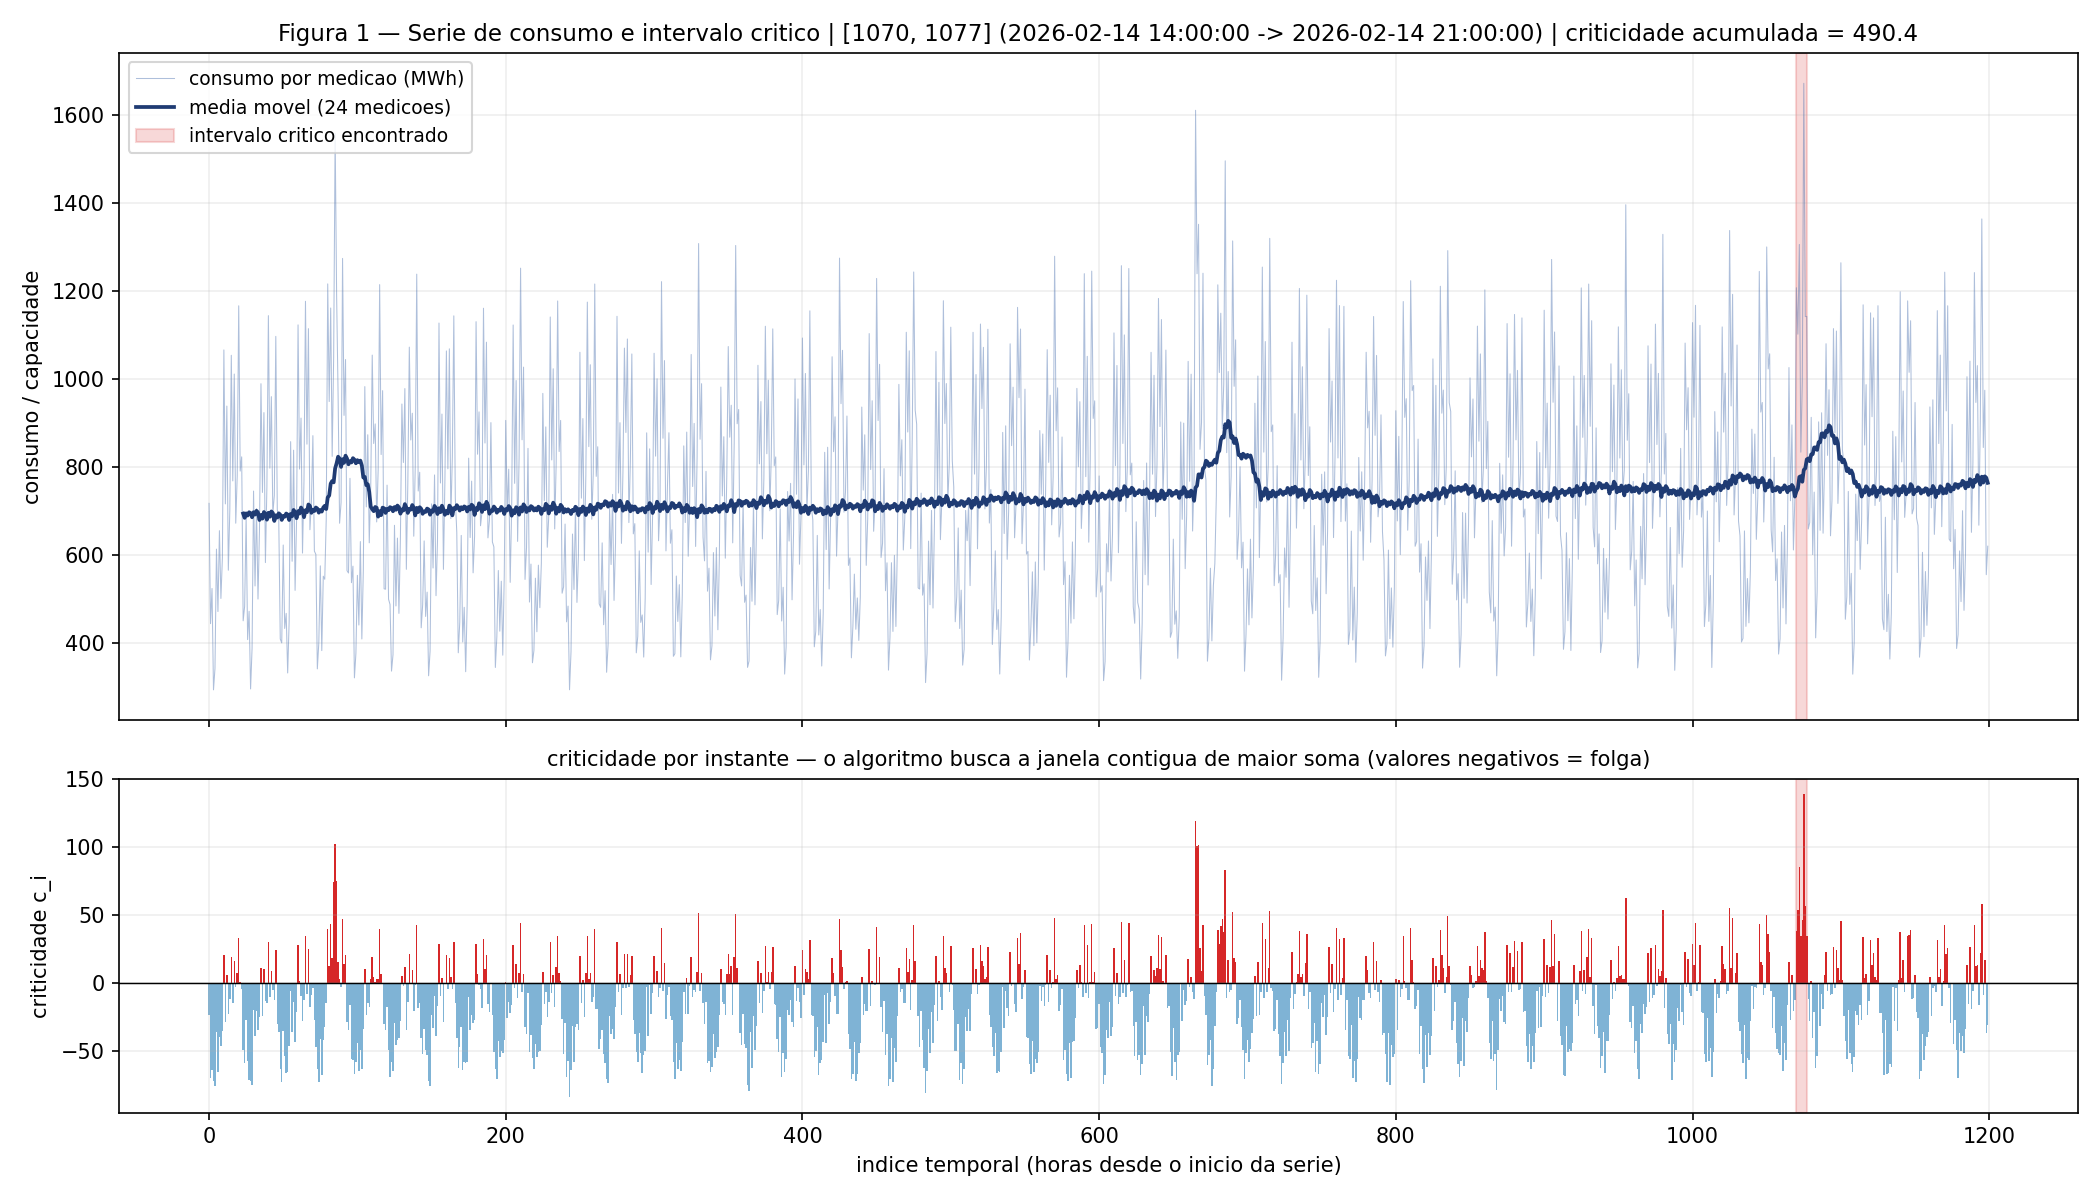

In [9]:
from src.visualizacao_q2 import (figura_serie, figura_recursao,
                                  figura_escalabilidade, figura_perfil_regiao)

f1 = figura_serie(serie, valores, dc)
f2 = figura_recursao(raiz, dc)
f3 = figura_escalabilidade(linhas)
f4 = figura_perfil_regiao(serie)
display(Image(f1))

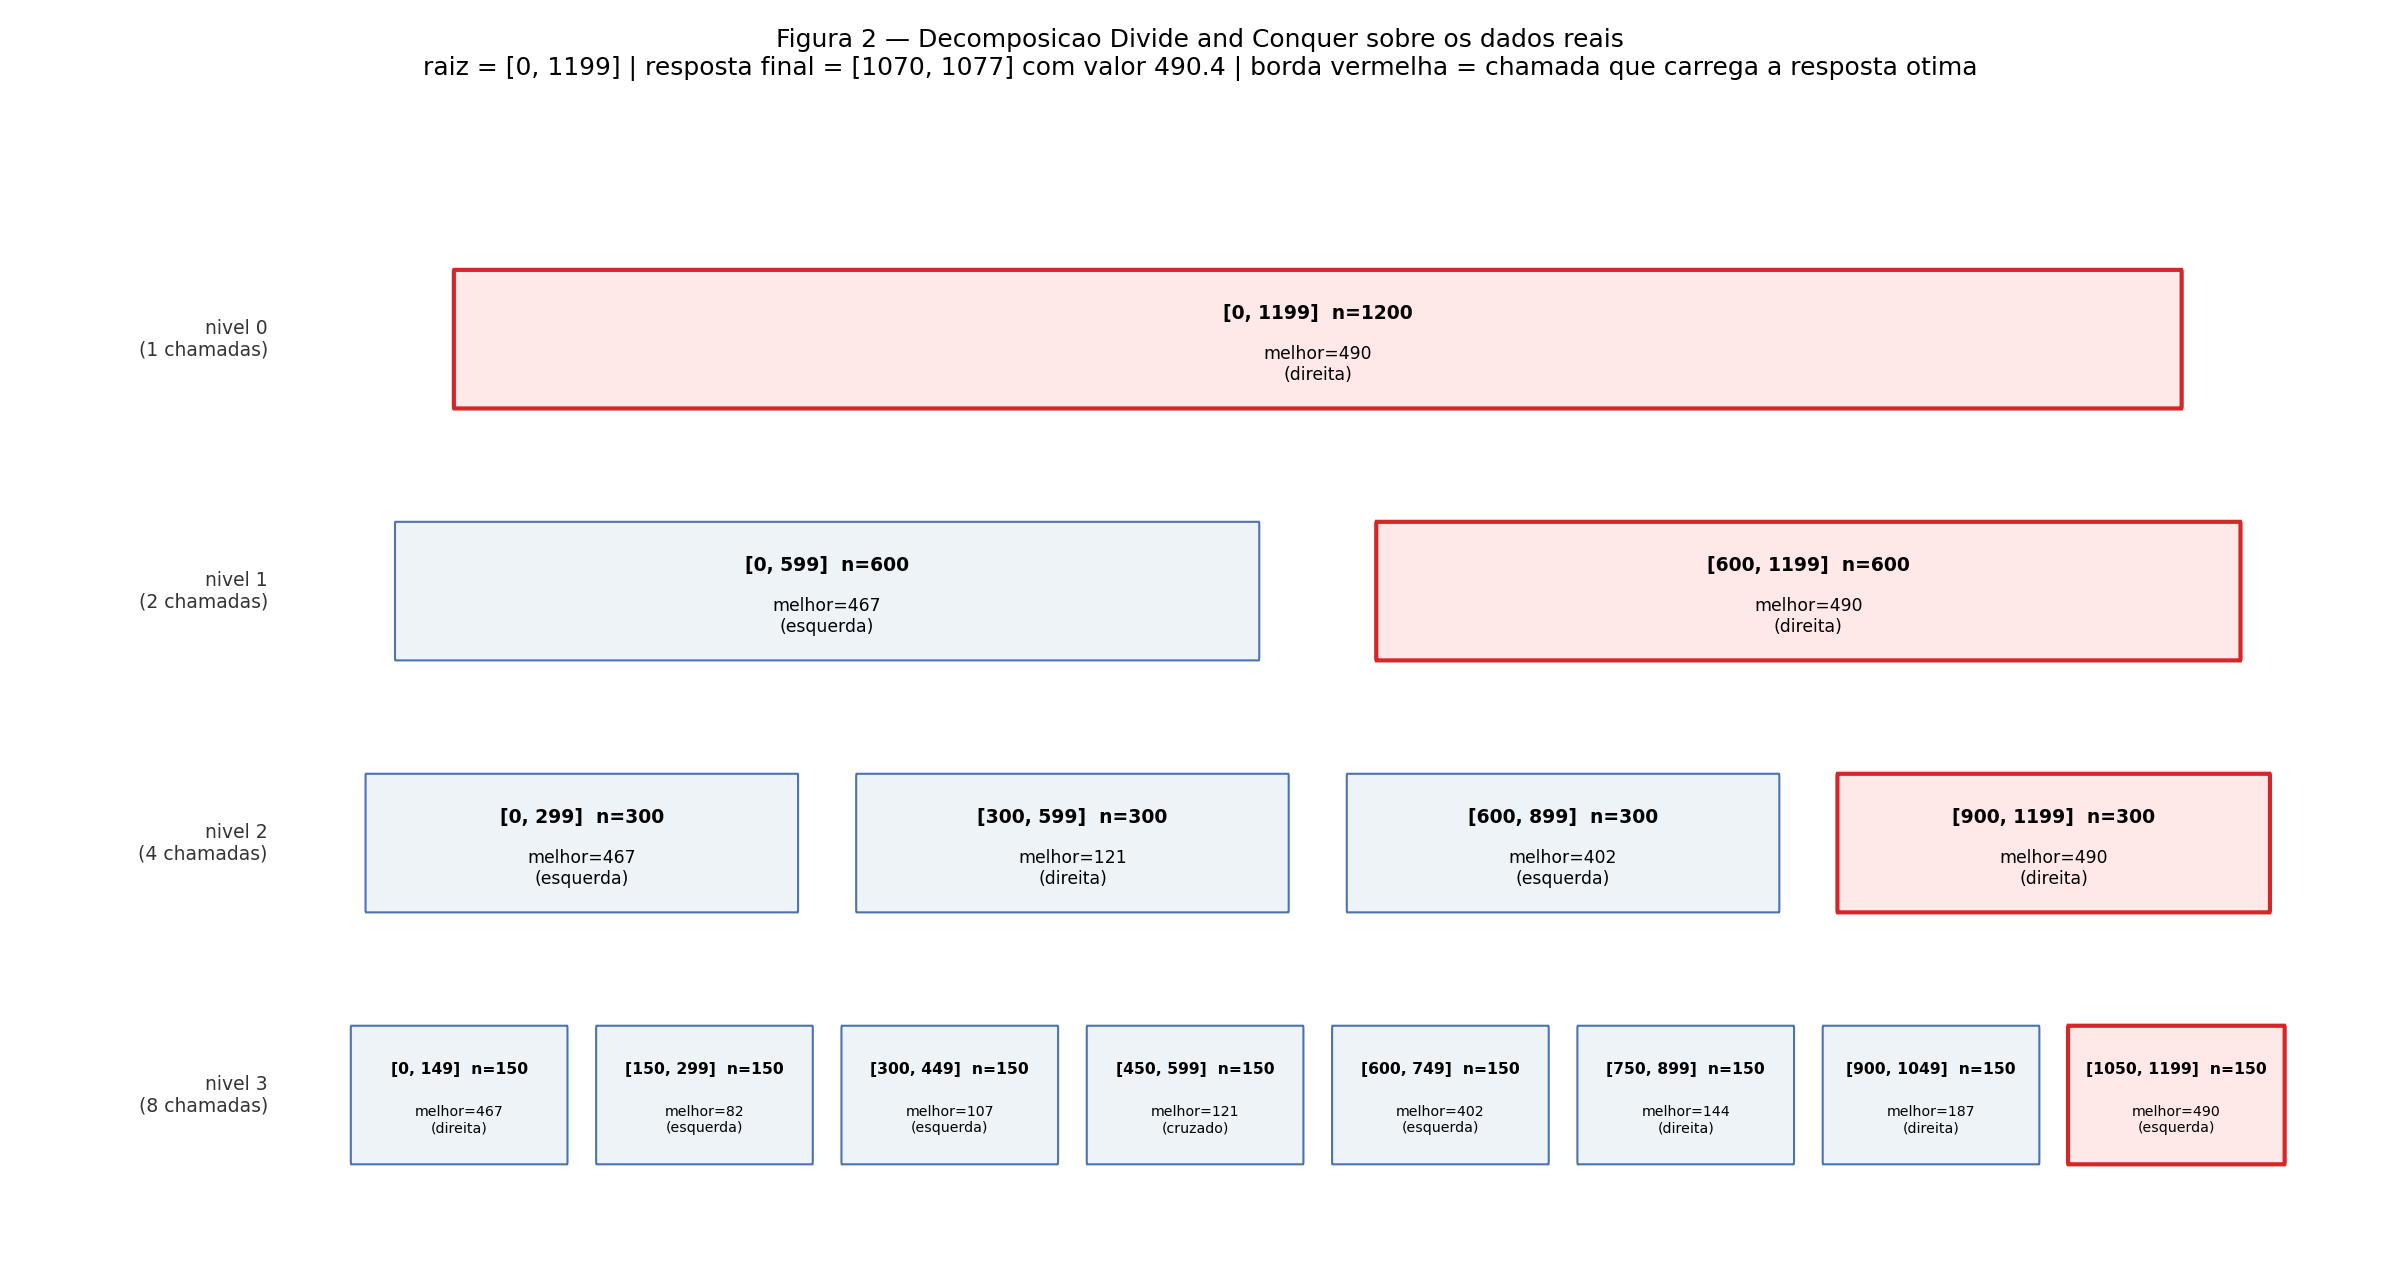

In [10]:
display(Image(f2))

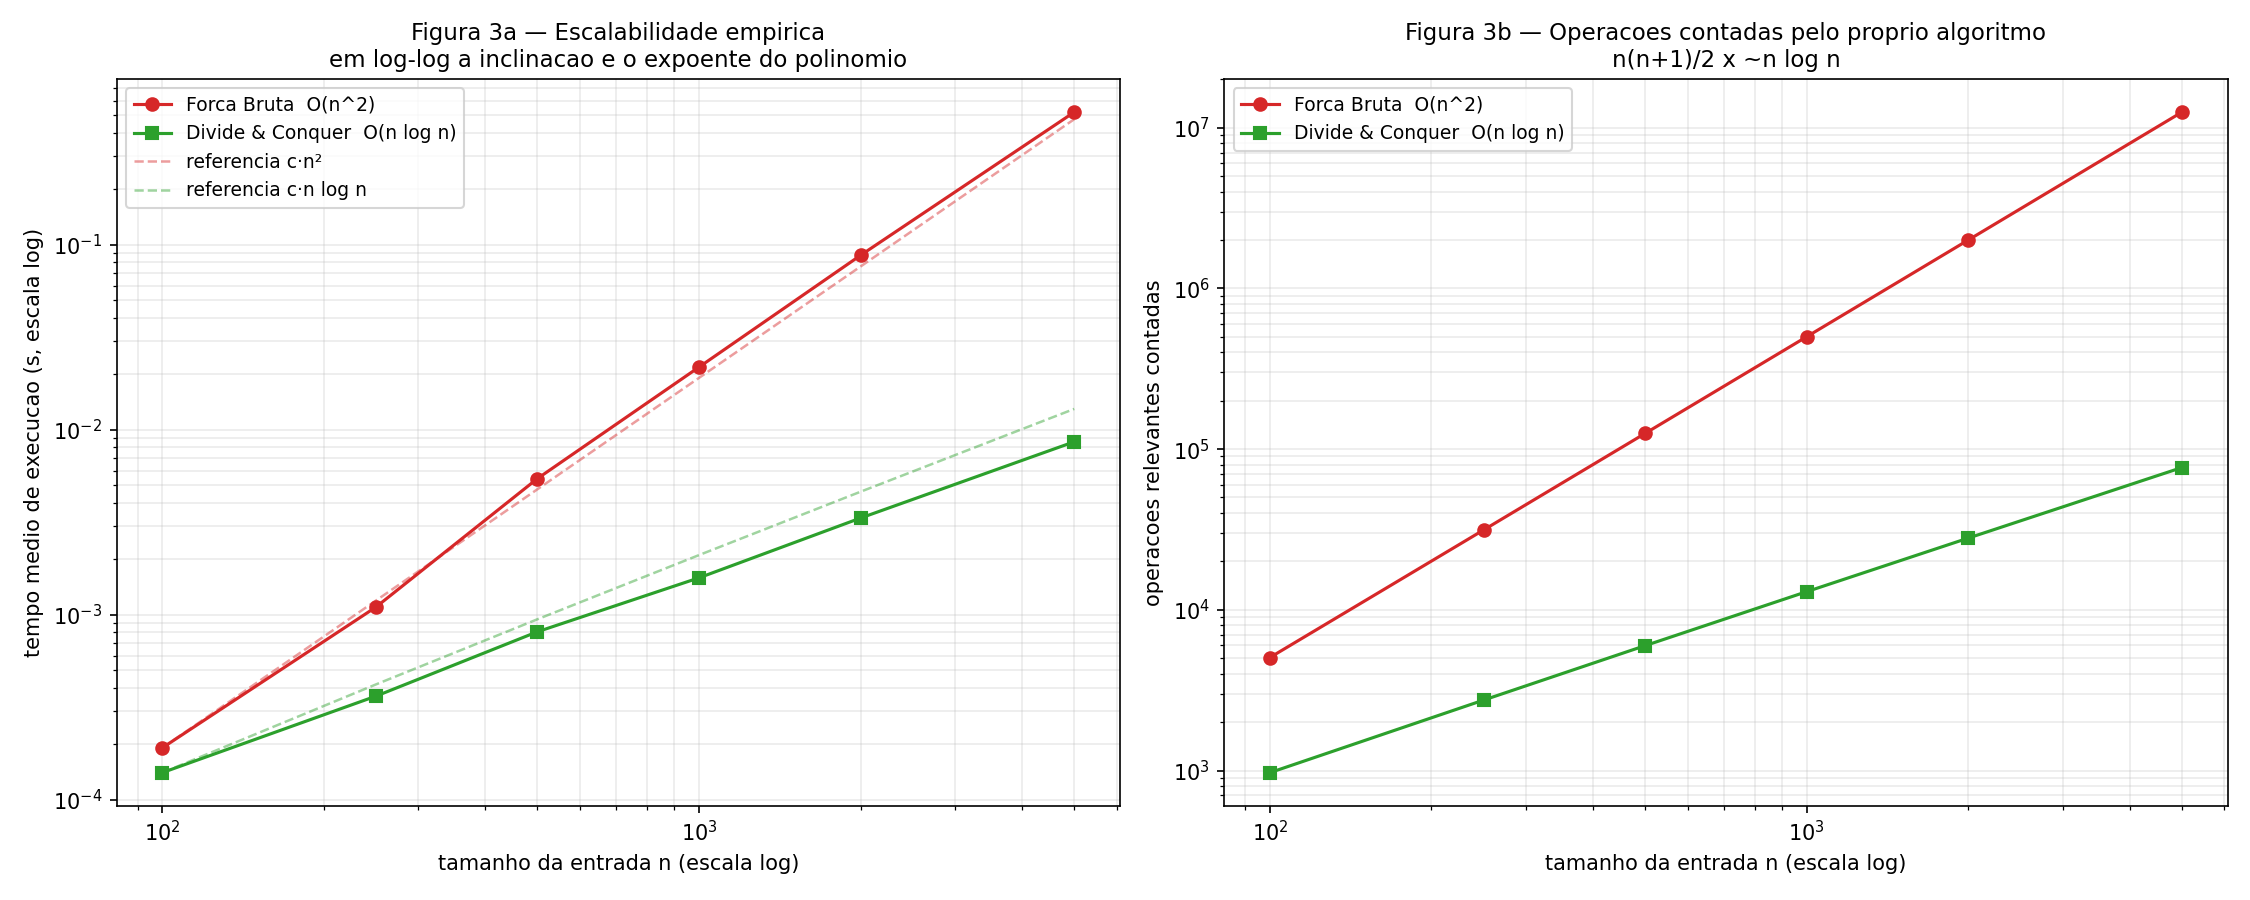

In [11]:
display(Image(f3))

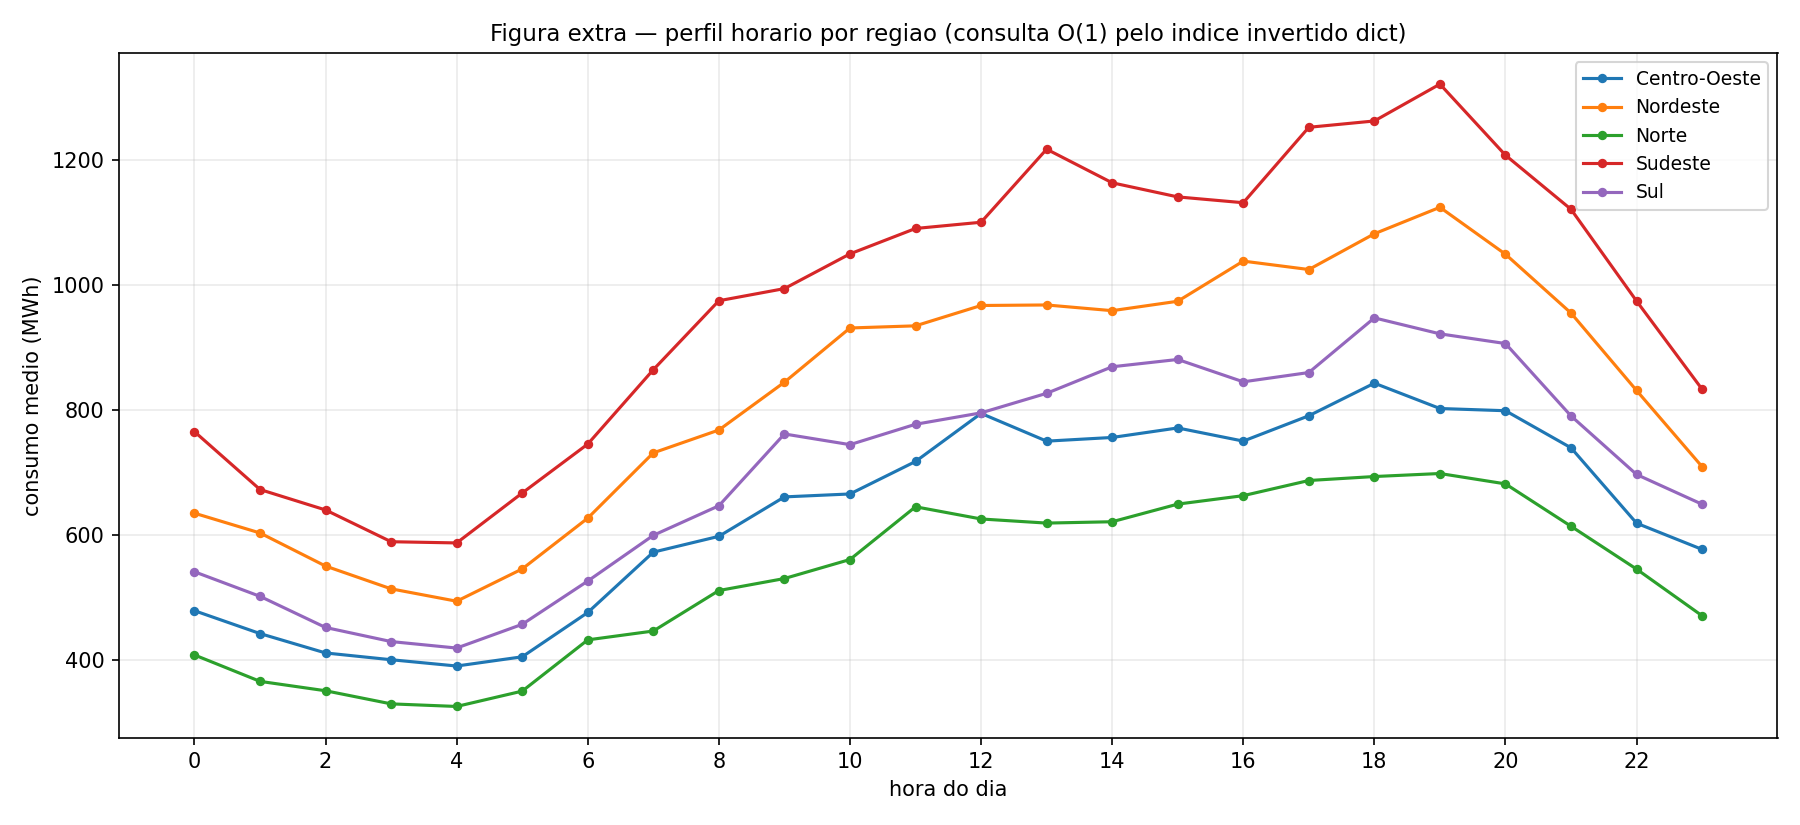

In [12]:
display(Image(f4))

## Análise Big O

### Força bruta — `Θ(n²)` tempo, `O(1)` espaço
O laço externo roda $n$ vezes; para cada $i$, o interno roda $n-i$ vezes. Total:
$\sum_{i=0}^{n-1}(n-i) = n(n+1)/2 \in \Theta(n^2)$ intervalos, cada um avaliado
em $O(1)$ graças à soma incremental. O contador do próprio código devolve
exatamente $n(n+1)/2$. Espaço: cinco escalares além da entrada, nenhuma
estrutura auxiliar, nenhuma recursão.

### Divide and conquer — `Θ(n log n)` tempo, `Θ(log n)` espaço
$T(n) = 2T(n/2) + \Theta(n)$: duas chamadas em metades e uma varredura linear
para o caso cruzado. Teorema Mestre, caso 2 ($a=2$, $b=2$,
$f(n)=\Theta(n^{\log_2 2})$) → $\Theta(n\log n)$. Pela árvore: são
$\lceil\log_2 n\rceil$ níveis e cada nível processa no total $n$ elementos no
caso cruzado. O número de chamadas é $2n-1$ e a profundidade
$\lceil\log_2 n\rceil$, ambos verificados pelo teste
`test_estrutura_da_recursao`. Espaço: não há vetores auxiliares (só índices);
o que cresce é a pilha, com uma moldura por nível ativo → $\Theta(\log n)$.

### Se o conjunto crescer de 1.000 para 1.000.000 de registros?

Medimos $\approx 0{,}585$ s para $n = 5000$ na força bruta. Como o custo é
quadrático, $n = 10^6$ significa multiplicar por $(10^6/5000)^2 = 40.000$:

$$0{,}585 \times 40.000 \approx 23.400\ \text{s} \approx 6{,}5\ \text{horas.}$$

O divide and conquer levou $\approx 0{,}010$ s para $n=5000$; o fator é
$200 \times \log_2(10^6)/\log_2(5000) \approx 200 \times 1{,}62 = 324$, ou seja
$\approx 3{,}2$ s. **Só o divide and conquer continua viável.** A memória não é
o gargalo em nenhum dos dois (a pilha vai a $\approx 20$ molduras), o gargalo é
puramente o número de intervalos que a força bruta insiste em enumerar.

Vale registrar o passo seguinte: o mesmo problema admite solução `Θ(n)` com um
único varrimento (Kadane), que seria a escolha para $10^6$ ou mais. Ela não foi
usada como algoritmo avaliado porque o enunciado pede explicitamente a
comparação força bruta × divide and conquer, mas é a direção natural de
evolução.

In [13]:
import math

t_bf_5000 = [l["tempo_medio_s"] for l in linhas if l["n"] == 5000 and l["algoritmo"] == "forca_bruta"][0]
t_dc_5000 = [l["tempo_medio_s"] for l in linhas if l["n"] == 5000 and l["algoritmo"] == "divide_conquer"][0]

fator_bf = (1_000_000 / 5000) ** 2
fator_dc = (1_000_000 / 5000) * (math.log2(1_000_000) / math.log2(5000))

print(f"forca bruta   : {t_bf_5000:.4f}s (n=5000) -> {t_bf_5000*fator_bf/3600:8.2f} horas para n=1e6")
print(f"divide&conquer: {t_dc_5000:.4f}s (n=5000) -> {t_dc_5000*fator_dc:8.2f} segundos para n=1e6")
print(f"\nprofundidade da pilha em n=1e6: {math.ceil(math.log2(1_000_000))} molduras")

forca bruta   : 0.5196s (n=5000) ->     5.77 horas para n=1e6
divide&conquer: 0.0086s (n=5000) ->     2.79 segundos para n=1e6

profundidade da pilha em n=1e6: 20 molduras
